# NYC Motor Vehicle Collision Data Analysis

## Flatiron School Capstone Project 1

This notebook analyzes New York City motor vehicle collision data. The goal of this project is to use core data analysis skills to clean the data, explore crash patterns, perform basic statistical analysis, and create visualizations that communicate meaningful traffic safety insights.

For this project, I am focusing on **data analysis only**. I am not including a machine learning model because the purpose of this first project is to demonstrate data cleaning, exploratory data analysis, statistical reasoning, and data visualization.

## Business Understanding

Traffic collisions are a major public safety issue in New York City. By analyzing collision records, we can better understand when crashes happen, where they happen, what factors are commonly reported, and which groups are most affected.

The main question guiding this project is:

> **What patterns in NYC motor vehicle collision data can help identify higher-risk locations, times, and contributing factors?**

To answer this, I will explore:

- Collision trends by borough
- Collision patterns by hour, day, and month
- Injury and fatality patterns
- Most common contributing factors
- Pedestrian, cyclist, and motorist injury patterns
- High-crash streets and intersections

The final output of this analysis can support a Tableau dashboard and a short presentation with data-driven recommendations.

## Data Understanding

The dataset used in this project is the NYC Motor Vehicle Collisions Crashes dataset. Each row represents one reported crash. The dataset includes crash date and time, borough, location, injury counts, fatality counts, contributing factors, and vehicle types.

Before doing analysis, I will inspect the structure of the dataset, check missing values, review data types, and identify columns that need cleaning or feature engineering.

In [1]:
# Import core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Display settings for readability
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

# Make charts easier to read
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True

In [2]:
# Load the dataset
# The file should be in the same folder as this notebook.

DATA_PATH = Path("Motor_Vehicle_Collisions_-_Crashes_20260514.csv")

# Fallback path for the original working environment
if not DATA_PATH.exists():
    DATA_PATH = Path("/mnt/data/Motor_Vehicle_Collisions_-_Crashes_20260514.csv")

df = pd.read_csv(DATA_PATH)

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")
df.head()

Rows: 28,853
Columns: 29


,CRASH DATE,CRASH TIME,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,LOCATION,ON STREET NAME,CROSS STREET NAME,OFF STREET NAME,NUMBER OF PERSONS INJURED,NUMBER OF PERSONS KILLED,NUMBER OF PEDESTRIANS INJURED,NUMBER OF PEDESTRIANS KILLED,NUMBER OF CYCLIST INJURED,NUMBER OF CYCLIST KILLED,NUMBER OF MOTORIST INJURED,NUMBER OF MOTORIST KILLED,CONTRIBUTING FACTOR VEHICLE 1,CONTRIBUTING FACTOR VEHICLE 2,CONTRIBUTING FACTOR VEHICLE 3,CONTRIBUTING FACTOR VEHICLE 4,CONTRIBUTING FACTOR VEHICLE 5,COLLISION_ID,VEHICLE TYPE CODE 1,VEHICLE TYPE CODE 2,VEHICLE TYPE CODE 3,VEHICLE TYPE CODE 4,VEHICLE TYPE CODE 5
0,01/02/2026,15:30,NaN,NaN,40.59,-73.94,"(40.586254, -73.93608)",BELT PARKWAY,NaN,NaN,0,0.00,0,0,0,0,0,0,Driver Inexperience,Failure to Yield Right-of-Way,NaN,NaN,NaN,4869140,Sedan,Sedan,NaN,NaN,NaN
1,01/02/2026,8:30,BROOKLYN,11235.00,40.59,-73.94,"(40.590134, -73.942085)",NaN,NaN,2554 E 28 ST,0,0.00,0,0,0,0,0,0,Backing Unsafely,Unspecified,NaN,NaN,NaN,4869138,Station Wagon/Sport Utility Vehicle,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN
2,01/02/2026,0:00,BROOKLYN,11203.00,40.66,-73.93,"(40.655396, -73.92976)",LENOX RD,E 51 ST,NaN,0,0.00,0,0,0,0,0,0,Unspecified,NaN,NaN,NaN,NaN,4869363,NaN,NaN,NaN,NaN,NaN
3,01/02/2026,18:09,MANHATTAN,10069.00,40.78,-73.99,"(40.77683, -73.989136)",W 66 ST,RIVERSIDE BLVD,NaN,0,0.00,0,0,0,0,0,0,Driver Inattention/Distraction,Driver Inattention/Distraction,NaN,NaN,NaN,4869025,Sedan,Sedan,NaN,NaN,NaN
4,01/02/2026,9:26,NaN,NaN,NaN,NaN,NaN,WOODHAVEN BLVD,LIE WB ENTRANCE WOODHAVEN BL N,NaN,0,0.00,0,0,0,0,0,0,Unspecified,Unspecified,NaN,NaN,NaN,4869553,Sedan,Standing S,NaN,NaN,NaN


In [3]:
# Review column names and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28853 entries, 0 to 28852
Data columns (total 29 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   CRASH DATE                     28853 non-null  object 
 1   CRASH TIME                     28853 non-null  object 
 2   BOROUGH                        21980 non-null  object 
 3   ZIP CODE                       21974 non-null  float64
 4   LATITUDE                       28576 non-null  float64
 5   LONGITUDE                      28576 non-null  float64
 6   LOCATION                       28576 non-null  object 
 7   ON STREET NAME                 19555 non-null  object 
 8   CROSS STREET NAME              15562 non-null  object 
 9   OFF STREET NAME                9298 non-null   object 
 10  NUMBER OF PERSONS INJURED      28853 non-null  int64  
 11  NUMBER OF PERSONS KILLED       27288 non-null  float64
 12  NUMBER OF PEDESTRIANS INJURED  28853 non-null 

In [4]:
# Summary statistics for numeric columns
df.describe()

,ZIP CODE,LATITUDE,LONGITUDE,NUMBER OF PERSONS INJURED,NUMBER OF PERSONS KILLED,NUMBER OF PEDESTRIANS INJURED,NUMBER OF PEDESTRIANS KILLED,NUMBER OF CYCLIST INJURED,NUMBER OF CYCLIST KILLED,NUMBER OF MOTORIST INJURED,NUMBER OF MOTORIST KILLED,COLLISION_ID
count,21974.00,28576.00,28576.00,28853.00,27288.00,28853.00,28853.00,28853.00,28853.00,28853.00,28853.00,28853.00
mean,10870.45,39.82,-72.27,0.55,0.00,0.11,0.00,0.05,0.00,0.38,0.00,4883942.71
std,533.30,6.01,10.91,0.84,0.05,0.32,0.03,0.22,0.02,0.82,0.03,8547.88
min,10000.00,0.00,-74.25,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,4597666.00
25%,10453.00,40.66,-73.97,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,4876728.00
50%,11207.00,40.71,-73.92,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,4883976.00
75%,11236.00,40.77,-73.86,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,4891204.00
max,11697.00,40.91,0.00,13.00,2.00,4.00,1.00,2.00,1.00,13.00,2.00,4898667.00


## Initial Observations

At this point, I want to understand the overall size and structure of the data. I also want to identify missing values because real-world government datasets often contain incomplete location fields, missing boroughs, or unspecified contributing factors.

In [5]:
# Check missing values by column
missing_summary = (
    df.isna().sum()
    .to_frame("missing_count")
    .assign(missing_percent=lambda x: x["missing_count"] / len(df) * 100)
    .sort_values("missing_percent", ascending=False)
)

missing_summary

,missing_count,missing_percent
VEHICLE TYPE CODE 5,28717,99.53
CONTRIBUTING FACTOR VEHICLE 5,28715,99.52
VEHICLE TYPE CODE 4,28363,98.30
CONTRIBUTING FACTOR VEHICLE 4,28330,98.19
VEHICLE TYPE CODE 3,26880,93.16
CONTRIBUTING FACTOR VEHICLE 3,26711,92.58
OFF STREET NAME,19555,67.77
CROSS STREET NAME,13291,46.06
VEHICLE TYPE CODE 2,10501,36.39
ON STREET NAME,9298,32.23


## Data Cleaning

For this analysis, I need to clean and prepare the data so that it can be used for charts and statistical analysis. The main cleaning steps are:

1. Standardize column names
2. Convert crash date and time into datetime features
3. Create total injury and fatality fields
4. Create a severity category
5. Clean text fields such as borough and contributing factor
6. Remove obviously invalid coordinates when using location-based analysis

In [6]:
# Create a working copy so the original dataframe stays unchanged
collisions = df.copy()

# Standardize column names for easier coding
collisions.columns = (
    collisions.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
)

collisions.columns.tolist()

['crash_date',
 'crash_time',
 'borough',
 'zip_code',
 'latitude',
 'longitude',
 'location',
 'on_street_name',
 'cross_street_name',
 'off_street_name',
 'number_of_persons_injured',
 'number_of_persons_killed',
 'number_of_pedestrians_injured',
 'number_of_pedestrians_killed',
 'number_of_cyclist_injured',
 'number_of_cyclist_killed',
 'number_of_motorist_injured',
 'number_of_motorist_killed',
 'contributing_factor_vehicle_1',
 'contributing_factor_vehicle_2',
 'contributing_factor_vehicle_3',
 'contributing_factor_vehicle_4',
 'contributing_factor_vehicle_5',
 'collision_id',
 'vehicle_type_code_1',
 'vehicle_type_code_2',
 'vehicle_type_code_3',
 'vehicle_type_code_4',
 'vehicle_type_code_5']

In [7]:
# Convert crash date and crash time into datetime fields
collisions["crash_date"] = pd.to_datetime(collisions["crash_date"], errors="coerce")

# Combine date and time into a single datetime column
collisions["crash_datetime"] = pd.to_datetime(
    collisions["crash_date"].astype(str) + " " + collisions["crash_time"].astype(str),
    errors="coerce"
)

# Create time-based features for analysis
collisions["year"] = collisions["crash_datetime"].dt.year
collisions["month"] = collisions["crash_datetime"].dt.month
collisions["month_name"] = collisions["crash_datetime"].dt.month_name()
collisions["day_of_week"] = collisions["crash_datetime"].dt.day_name()
collisions["hour"] = collisions["crash_datetime"].dt.hour
collisions["is_weekend"] = collisions["day_of_week"].isin(["Saturday", "Sunday"])

# Define rush hour as morning and evening commute periods
collisions["is_rush_hour"] = collisions["hour"].between(7, 9) | collisions["hour"].between(16, 18)

collisions[["crash_date", "crash_time", "crash_datetime", "day_of_week", "hour", "is_rush_hour"]].head()

,crash_date,crash_time,crash_datetime,day_of_week,hour,is_rush_hour
0,2026-01-02,15:30,2026-01-02 15:30:00,Friday,15,False
1,2026-01-02,8:30,2026-01-02 08:30:00,Friday,8,True
2,2026-01-02,0:00,2026-01-02 00:00:00,Friday,0,False
3,2026-01-02,18:09,2026-01-02 18:09:00,Friday,18,True
4,2026-01-02,9:26,2026-01-02 09:26:00,Friday,9,True


In [8]:
# Create total injury and fatality fields
injury_cols = [
    "number_of_persons_injured",
    "number_of_pedestrians_injured",
    "number_of_cyclist_injured",
    "number_of_motorist_injured"
]

fatality_cols = [
    "number_of_persons_killed",
    "number_of_pedestrians_killed",
    "number_of_cyclist_killed",
    "number_of_motorist_killed"
]

# Fill missing injury/fatality values with 0 because blank counts should not be treated as separate categories
for col in injury_cols + fatality_cols:
    collisions[col] = collisions[col].fillna(0)

collisions["total_injured"] = collisions["number_of_persons_injured"]
collisions["total_killed"] = collisions["number_of_persons_killed"]
collisions["has_injury"] = collisions["total_injured"] > 0
collisions["has_fatality"] = collisions["total_killed"] > 0

# Create a simple severity label for analysis
conditions = [
    collisions["total_killed"] > 0,
    collisions["total_injured"] > 0
]
choices = ["Fatal", "Injury"]
collisions["severity"] = np.select(conditions, choices, default="No Injury Reported")

collisions["severity"].value_counts()

severity
No Injury Reported    17067
Injury                11722
Fatal                    64
Name: count, dtype: int64

In [9]:
# Clean key categorical columns
collisions["borough"] = collisions["borough"].fillna("Unknown")
collisions["contributing_factor_vehicle_1"] = collisions["contributing_factor_vehicle_1"].fillna("Unspecified")
collisions["vehicle_type_code_1"] = collisions["vehicle_type_code_1"].fillna("Unknown")

# Create a cleaned location dataframe for map-based analysis
# NYC coordinates should have latitude around 40 and longitude around -74.
collisions_geo = collisions.dropna(subset=["latitude", "longitude"]).copy()
collisions_geo = collisions_geo[
    collisions_geo["latitude"].between(40.4, 41.0) &
    collisions_geo["longitude"].between(-74.3, -73.6)
]

print(f"Rows with usable coordinates: {len(collisions_geo):,}")
print(f"Rows removed from geo analysis: {len(collisions) - len(collisions_geo):,}")

Rows with usable coordinates: 27,939
Rows removed from geo analysis: 914


## Cleaned Dataset Overview

After cleaning, I now have extra fields that make the analysis easier: hour, day of week, month, weekend flag, rush hour flag, total injuries, total fatalities, and severity.

In [10]:
# Check the date range after cleaning
print("Earliest crash date:", collisions["crash_date"].min())
print("Latest crash date:", collisions["crash_date"].max())
print("Total crashes:", f"{len(collisions):,}")
print("Total injuries:", f"{collisions['total_injured'].sum():,.0f}")
print("Total fatalities:", f"{collisions['total_killed'].sum():,.0f}")

Earliest crash date: 2026-01-02 00:00:00
Latest crash date: 2026-05-11 00:00:00
Total crashes: 28,853
Total injuries: 15,865
Total fatalities: 65


In [11]:
# Overall severity distribution
severity_counts = collisions["severity"].value_counts()
severity_counts

severity
No Injury Reported    17067
Injury                11722
Fatal                    64
Name: count, dtype: int64

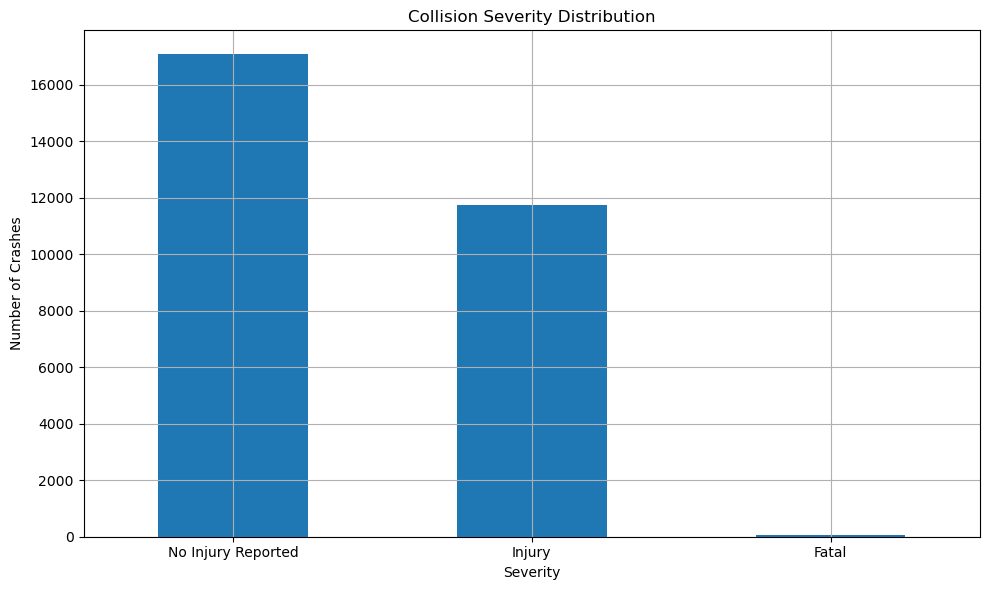

In [12]:
# Plot severity distribution
severity_counts.plot(kind="bar")
plt.title("Collision Severity Distribution")
plt.xlabel("Severity")
plt.ylabel("Number of Crashes")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Exploratory Data Analysis

In this section, I explore the data from several angles: borough, time, severity, contributing factors, and street-level crash patterns. The goal is to identify patterns that can be turned into clear findings and recommendations.

### Crashes by Borough

First, I want to compare crash volume by borough. This helps show whether collisions are evenly distributed across NYC or concentrated in certain areas.

In [13]:
borough_counts = collisions["borough"].value_counts()
borough_counts

borough
BROOKLYN         7713
Unknown          6873
QUEENS           5618
MANHATTAN        4133
BRONX            3608
STATEN ISLAND     908
Name: count, dtype: int64

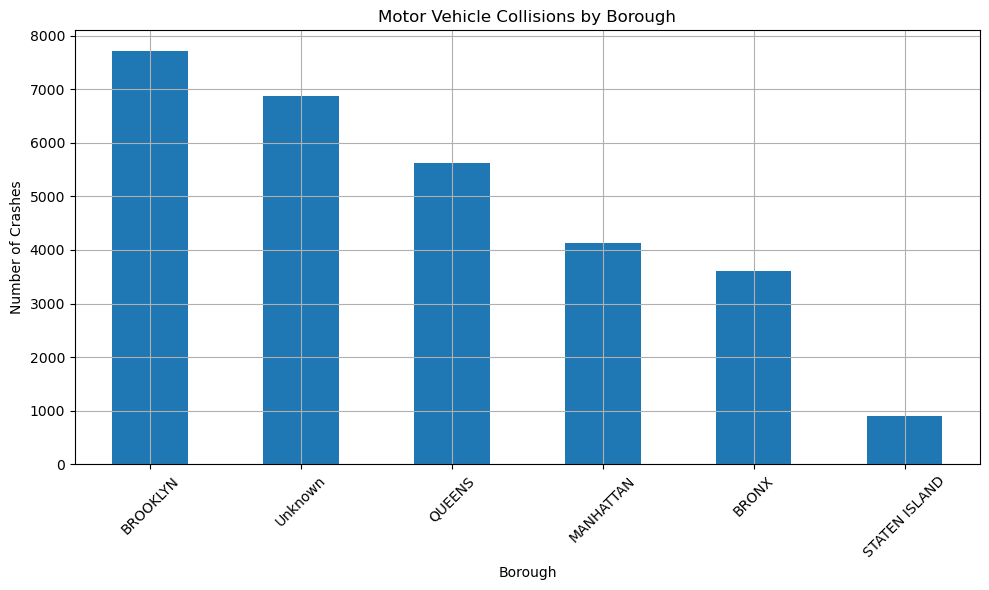

In [14]:
borough_counts.plot(kind="bar")
plt.title("Motor Vehicle Collisions by Borough")
plt.xlabel("Borough")
plt.ylabel("Number of Crashes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [15]:
# Injury and fatality totals by borough
borough_severity = (
    collisions.groupby("borough")
    .agg(
        crashes=("collision_id", "count"),
        total_injuries=("total_injured", "sum"),
        total_fatalities=("total_killed", "sum"),
        injury_crashes=("has_injury", "sum"),
        fatal_crashes=("has_fatality", "sum")
    )
    .assign(
        injury_crash_rate=lambda x: x["injury_crashes"] / x["crashes"],
        fatal_crash_rate=lambda x: x["fatal_crashes"] / x["crashes"]
    )
    .sort_values("crashes", ascending=False)
)

borough_severity

,crashes,total_injuries,total_fatalities,injury_crashes,fatal_crashes,injury_crash_rate,fatal_crash_rate
borough,,,,,,,
BROOKLYN,7713,4085,13.00,3088,13,0.40,0.00
Unknown,6873,4763,30.00,3137,29,0.46,0.00
QUEENS,5618,2697,11.00,2123,11,0.38,0.00
MANHATTAN,4133,1943,6.00,1623,6,0.39,0.00
BRONX,3608,1994,5.00,1471,5,0.41,0.00
STATEN ISLAND,908,383,0.00,295,0,0.32,0.00


### Crashes by Time of Day

Next, I analyze crashes by hour. This can show whether crashes are more common during commute times, late night hours, or other high-traffic periods.

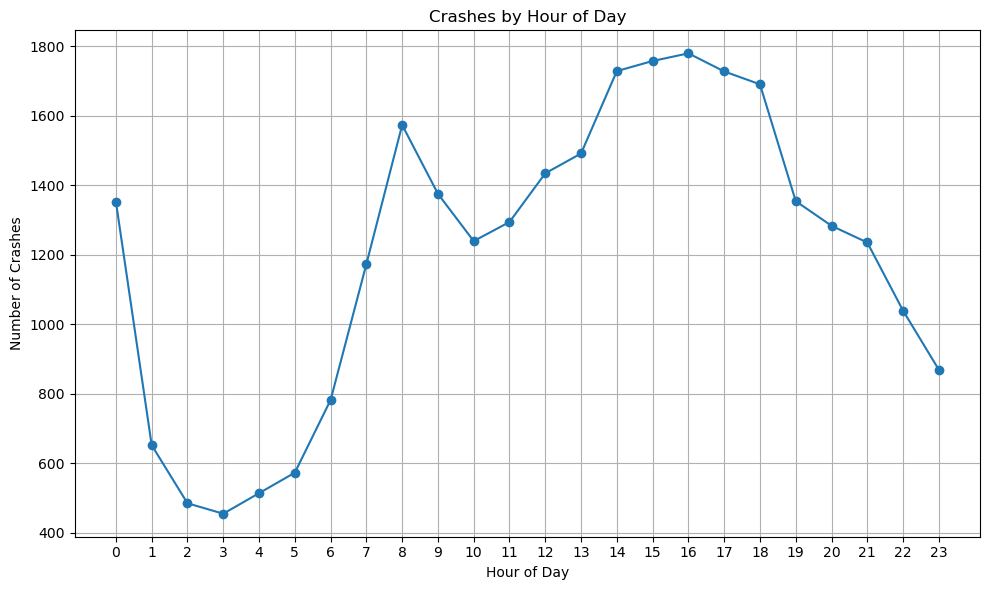

In [16]:
hourly_crashes = collisions.groupby("hour").size()

hourly_crashes.plot(kind="line", marker="o")
plt.title("Crashes by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Crashes")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

In [17]:
# Compare rush hour vs non-rush hour crashes
rush_hour_summary = (
    collisions.groupby("is_rush_hour")
    .agg(
        crashes=("collision_id", "count"),
        injury_crashes=("has_injury", "sum"),
        fatalities=("total_killed", "sum")
    )
    .assign(injury_crash_rate=lambda x: x["injury_crashes"] / x["crashes"])
)

rush_hour_summary

,crashes,injury_crashes,fatalities,injury_crash_rate
is_rush_hour,,,,
False,19536,7896,49.00,0.40
True,9317,3841,16.00,0.41


### Crashes by Day of Week

Looking at crashes by day of week helps identify weekly patterns. This can support recommendations related to enforcement, safety campaigns, or commuter-focused planning.

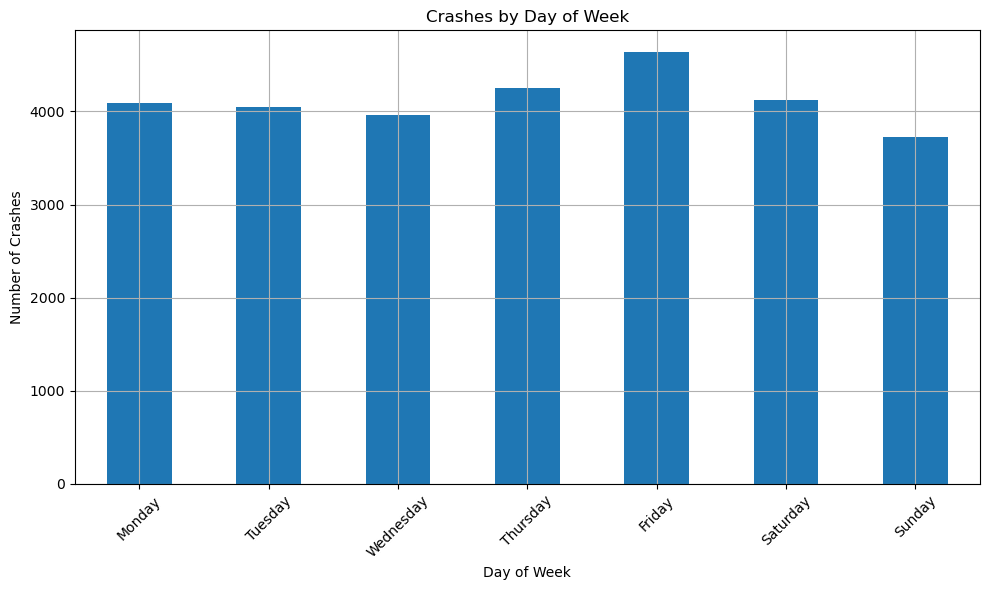

In [18]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_crashes = collisions["day_of_week"].value_counts().reindex(day_order)

weekday_crashes.plot(kind="bar")
plt.title("Crashes by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Crashes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [19]:
# Weekend vs weekday summary
weekend_summary = (
    collisions.groupby("is_weekend")
    .agg(
        crashes=("collision_id", "count"),
        injury_crashes=("has_injury", "sum"),
        fatalities=("total_killed", "sum")
    )
    .assign(injury_crash_rate=lambda x: x["injury_crashes"] / x["crashes"])
)

weekend_summary

,crashes,injury_crashes,fatalities,injury_crash_rate
is_weekend,,,,
False,21003,8707,46.00,0.41
True,7850,3030,19.00,0.39


### Monthly Trend

This dataset covers a specific time period, so I also look at monthly trends. This helps identify whether crash volume changed over time in the available data.

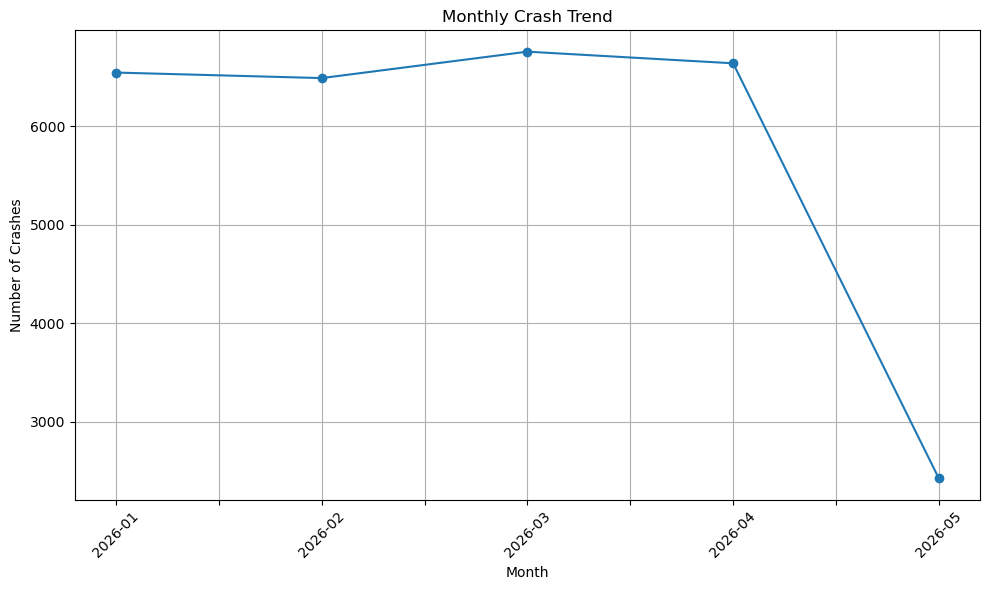

In [20]:
monthly_crashes = collisions.groupby(collisions["crash_date"].dt.to_period("M")).size()
monthly_crashes.index = monthly_crashes.index.astype(str)

monthly_crashes.plot(kind="line", marker="o")
plt.title("Monthly Crash Trend")
plt.xlabel("Month")
plt.ylabel("Number of Crashes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Heatmap: Hour by Day of Week

A heatmap is useful because it combines two time dimensions. This lets me see when crashes are most concentrated during the week.

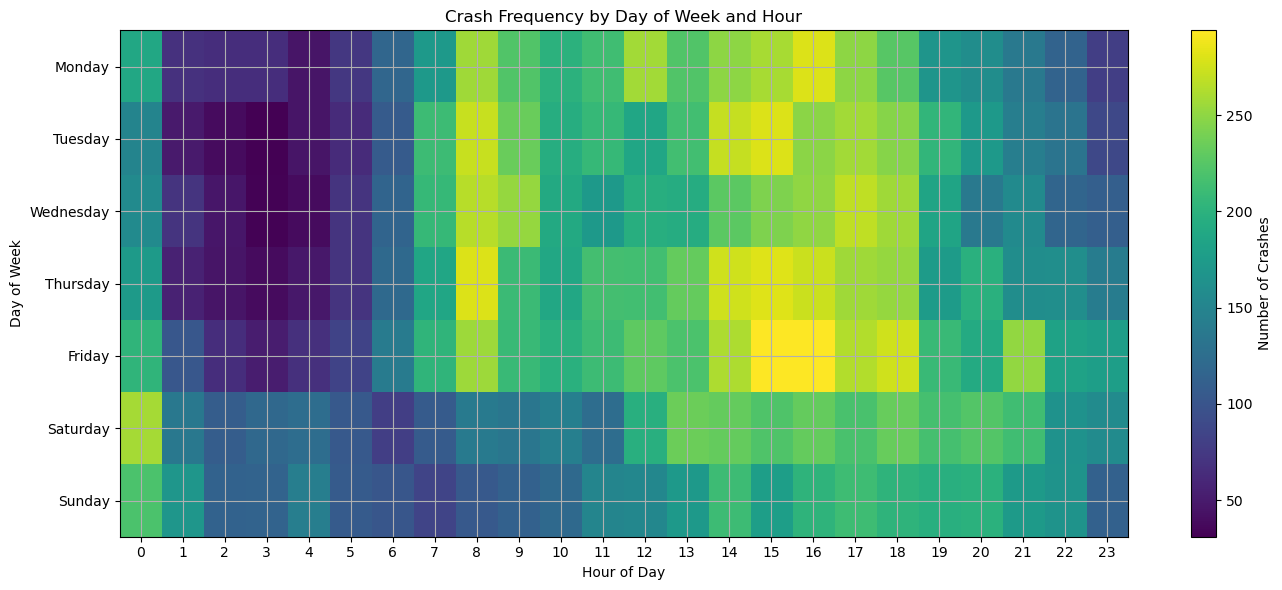

In [21]:
# Create a pivot table for crashes by day and hour
hour_day_pivot = collisions.pivot_table(
    index="day_of_week",
    columns="hour",
    values="collision_id",
    aggfunc="count",
    fill_value=0
).reindex(day_order)

plt.figure(figsize=(14, 6))
plt.imshow(hour_day_pivot, aspect="auto")
plt.colorbar(label="Number of Crashes")
plt.title("Crash Frequency by Day of Week and Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")
plt.xticks(ticks=range(24), labels=range(24))
plt.yticks(ticks=range(len(day_order)), labels=day_order)
plt.tight_layout()
plt.show()

### Contributing Factors

The contributing factor field is important because it gives context about why crashes may have happened. Some values are listed as "Unspecified", so I will review both the full ranking and a version that removes unspecified records.

In [22]:
# Top contributing factors including unspecified
top_factors = collisions["contributing_factor_vehicle_1"].value_counts().head(15)
top_factors

contributing_factor_vehicle_1
Unspecified                       8162
Driver Inattention/Distraction    6767
Failure to Yield Right-of-Way     1742
Following Too Closely             1423
Other Vehicular                   1217
Passing or Lane Usage Improper    1032
Passing Too Closely               1004
Backing Unsafely                   977
Unsafe Speed                       779
Driver Inexperience                682
Turning Improperly                 667
Traffic Control Disregarded        630
Alcohol Involvement                599
Unsafe Lane Changing               578
Pavement Slippery                  456
Name: count, dtype: int64

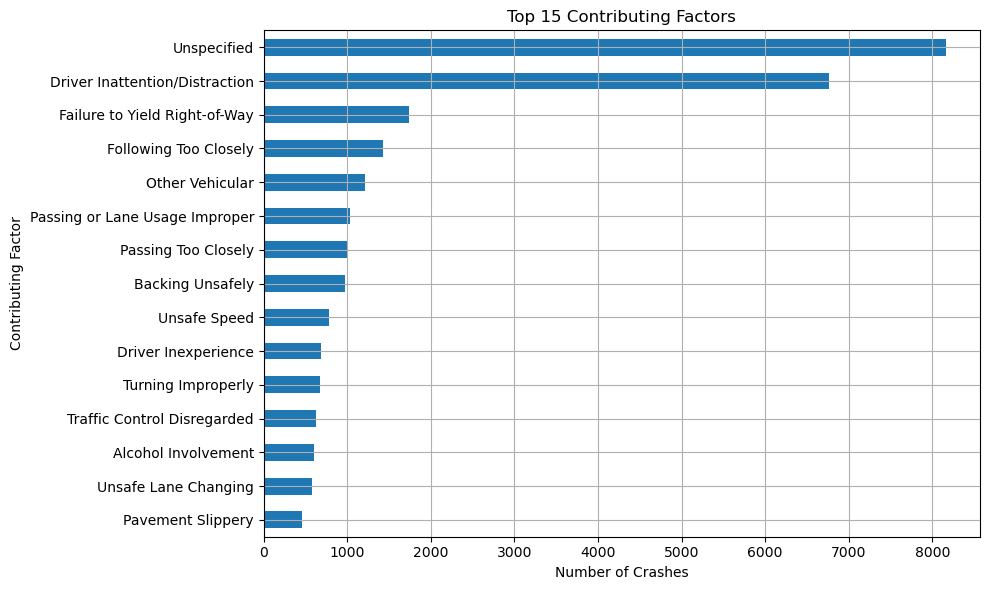

In [23]:
top_factors.sort_values().plot(kind="barh")
plt.title("Top 15 Contributing Factors")
plt.xlabel("Number of Crashes")
plt.ylabel("Contributing Factor")
plt.tight_layout()
plt.show()

In [24]:
# Top contributing factors excluding unspecified values
specified_factors = collisions[
    collisions["contributing_factor_vehicle_1"].str.lower() != "unspecified"
]

top_specified_factors = specified_factors["contributing_factor_vehicle_1"].value_counts().head(15)
top_specified_factors

contributing_factor_vehicle_1
Driver Inattention/Distraction                           6767
Failure to Yield Right-of-Way                            1742
Following Too Closely                                    1423
Other Vehicular                                          1217
Passing or Lane Usage Improper                           1032
Passing Too Closely                                      1004
Backing Unsafely                                          977
Unsafe Speed                                              779
Driver Inexperience                                       682
Turning Improperly                                        667
Traffic Control Disregarded                               630
Alcohol Involvement                                       599
Unsafe Lane Changing                                      578
Pavement Slippery                                         456
Pedestrian/Bicyclist/Other Pedestrian Error/Confusion     286
Name: count, dtype: int64

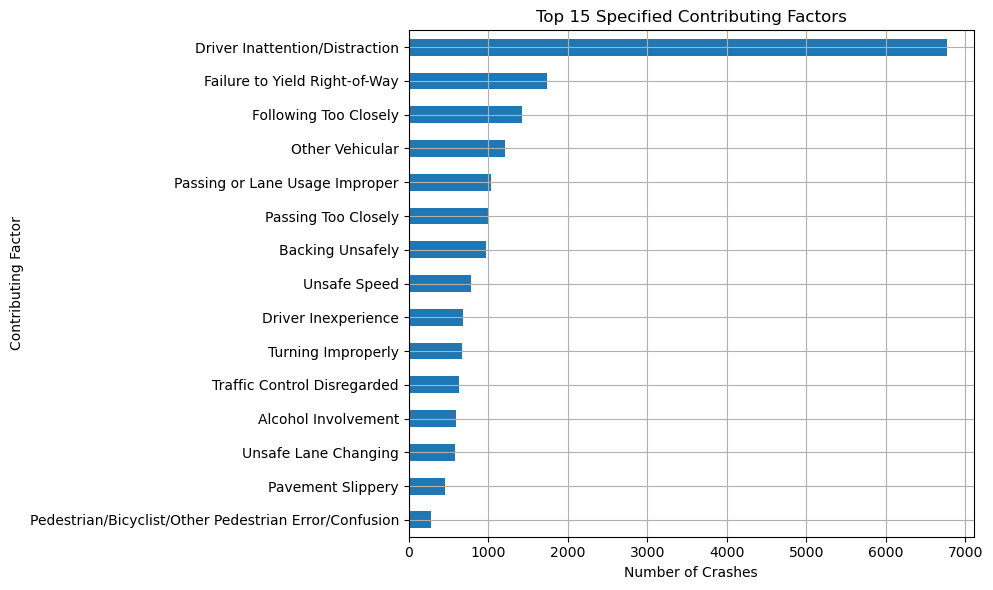

In [25]:
top_specified_factors.sort_values().plot(kind="barh")
plt.title("Top 15 Specified Contributing Factors")
plt.xlabel("Number of Crashes")
plt.ylabel("Contributing Factor")
plt.tight_layout()
plt.show()

### Injuries by Road User Type

The dataset separates injuries and fatalities by pedestrians, cyclists, and motorists. This is useful because different types of road users face different risks.

In [26]:
road_user_injuries = pd.Series({
    "Pedestrians Injured": collisions["number_of_pedestrians_injured"].sum(),
    "Cyclists Injured": collisions["number_of_cyclist_injured"].sum(),
    "Motorists Injured": collisions["number_of_motorist_injured"].sum()
}).sort_values(ascending=False)

road_user_injuries

Motorists Injured      11041
Pedestrians Injured     3110
Cyclists Injured        1359
dtype: int64

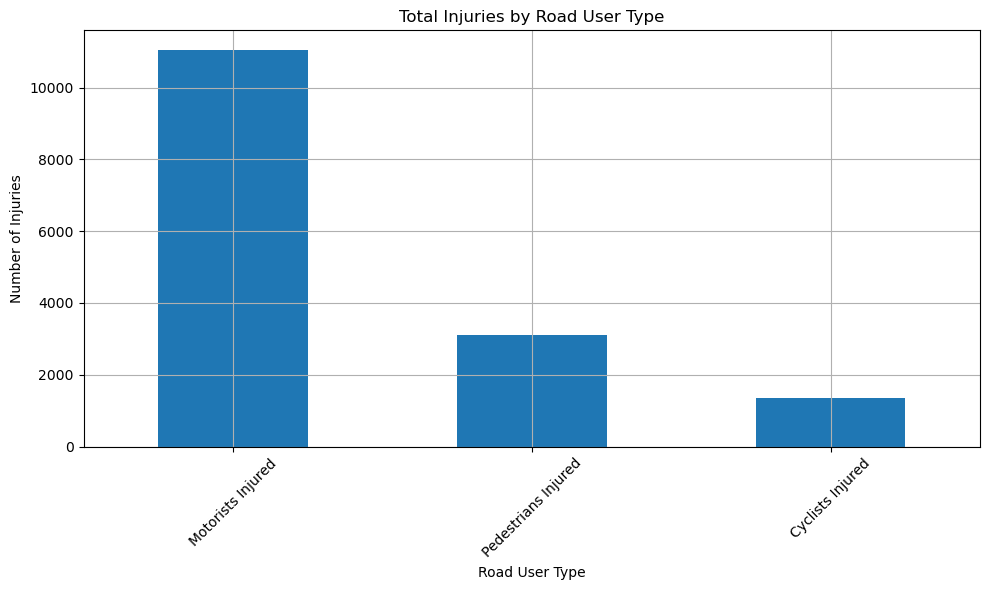

In [27]:
road_user_injuries.plot(kind="bar")
plt.title("Total Injuries by Road User Type")
plt.xlabel("Road User Type")
plt.ylabel("Number of Injuries")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [28]:
road_user_fatalities = pd.Series({
    "Pedestrians Killed": collisions["number_of_pedestrians_killed"].sum(),
    "Cyclists Killed": collisions["number_of_cyclist_killed"].sum(),
    "Motorists Killed": collisions["number_of_motorist_killed"].sum()
}).sort_values(ascending=False)

road_user_fatalities

Pedestrians Killed    31
Motorists Killed      24
Cyclists Killed        8
dtype: int64

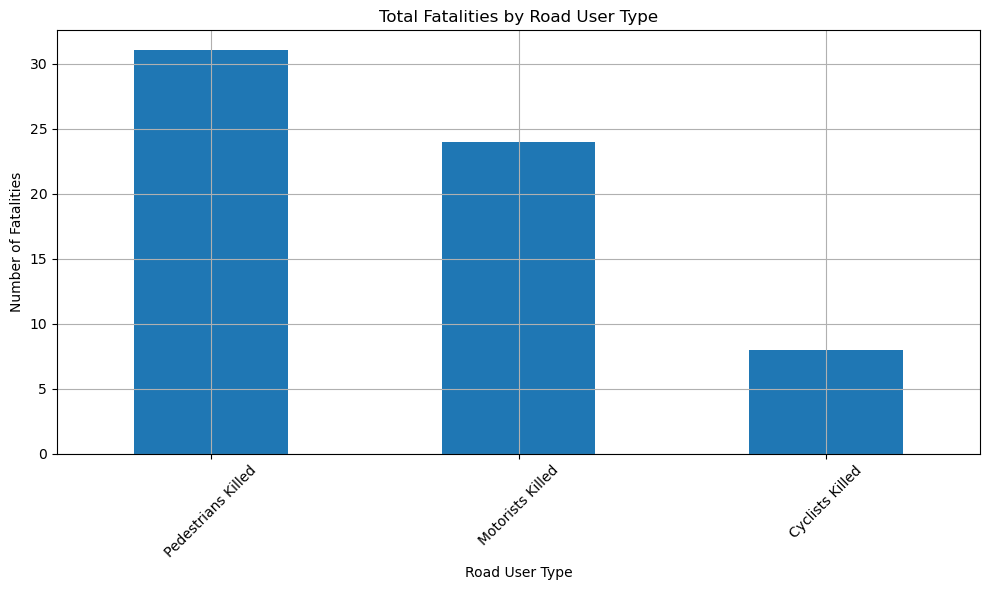

In [29]:
road_user_fatalities.plot(kind="bar")
plt.title("Total Fatalities by Road User Type")
plt.xlabel("Road User Type")
plt.ylabel("Number of Fatalities")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Vehicle Types

Vehicle type can provide another view of crash patterns. I will focus on the first listed vehicle type because it is the most consistently populated vehicle type field.

In [30]:
top_vehicle_types = collisions["vehicle_type_code_1"].value_counts().head(15)
top_vehicle_types

vehicle_type_code_1
Sedan                                  12291
Station Wagon/Sport Utility Vehicle     9758
Taxi                                     889
Pick-up Truck                            730
4 dr sedan                               669
Bus                                      637
Unknown                                  551
Box Truck                                432
Bike                                     404
Van                                      229
Motorcycle                               219
Moped                                    203
Tractor Truck Diesel                     176
E-Bike                                   155
Standing S                               148
Name: count, dtype: int64

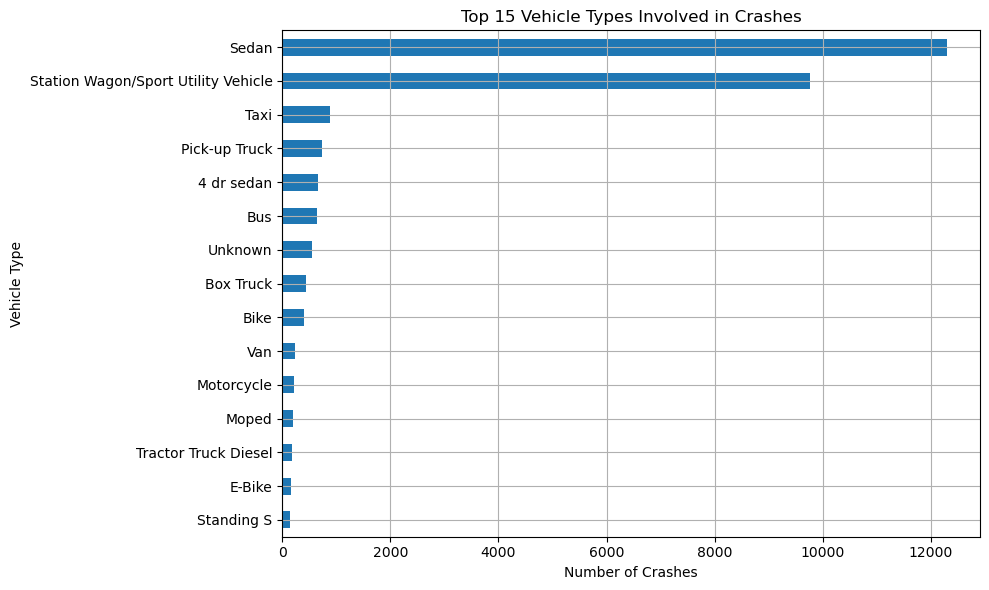

In [31]:
top_vehicle_types.sort_values().plot(kind="barh")
plt.title("Top 15 Vehicle Types Involved in Crashes")
plt.xlabel("Number of Crashes")
plt.ylabel("Vehicle Type")
plt.tight_layout()
plt.show()

### High-Crash Streets and Intersections

For street-level analysis, I review the most common on-street names and cross-street combinations. This can help identify crash hotspots that would be useful in a Tableau dashboard.

In [32]:
# Top streets by crash count
top_streets = (
    collisions["on_street_name"]
    .dropna()
    .str.strip()
    .value_counts()
    .head(15)
)

top_streets

on_street_name
BELT PARKWAY                  304
LONG ISLAND EXPRESSWAY        265
BROOKLYN QUEENS EXPRESSWAY    240
GRAND CENTRAL PKWY            219
BROADWAY                      206
ATLANTIC AVE                  176
CROSS BRONX EXPY              173
FDR DRIVE                     156
MAJOR DEEGAN EXPRESSWAY       151
CROSS ISLAND PARKWAY          142
3 AVE                         119
NORTHERN BLVD                 113
LINDEN BLVD                   113
VAN WYCK EXPWY                111
FLATBUSH AVE                  108
Name: count, dtype: int64

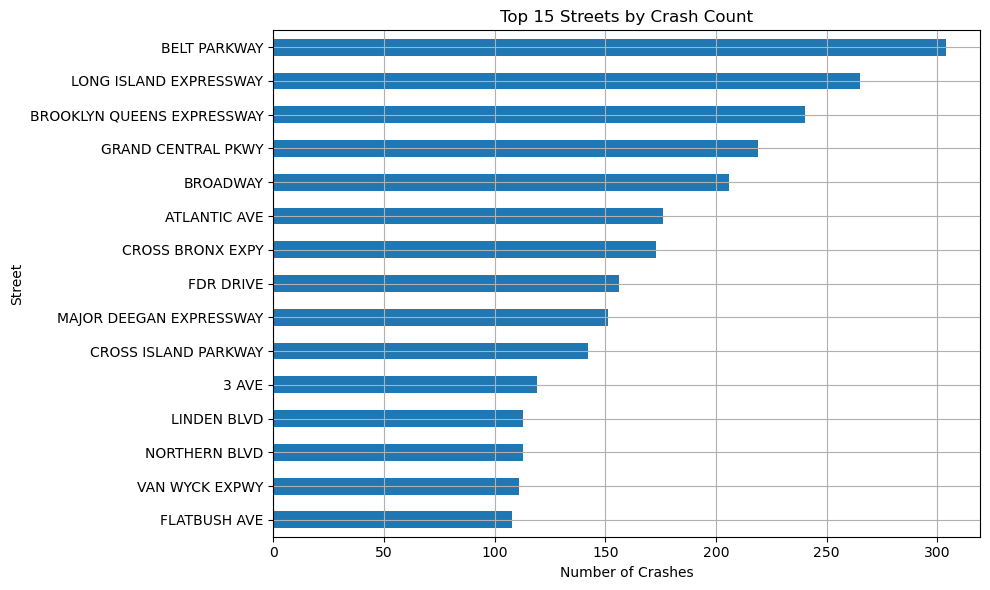

In [33]:
top_streets.sort_values().plot(kind="barh")
plt.title("Top 15 Streets by Crash Count")
plt.xlabel("Number of Crashes")
plt.ylabel("Street")
plt.tight_layout()
plt.show()

In [34]:
# Create an intersection field using on street and cross street
collisions["intersection"] = (
    collisions["on_street_name"].fillna("").str.strip() + " & " +
    collisions["cross_street_name"].fillna("").str.strip()
)

# Remove incomplete intersections
valid_intersections = collisions[
    (collisions["on_street_name"].notna()) &
    (collisions["cross_street_name"].notna())
].copy()

top_intersections = valid_intersections["intersection"].value_counts().head(15)
top_intersections

intersection
GRAND CENTRAL PARKWAY & JEWEL AVENUE    14
W FORDHAM RD & MAJOR DEEGAN EXPY        13
20 AVENUE & I 678                       13
CROSS ISLAND PKWY & HEMPSTEAD AVE       12
ROCKAWAY BOULEVARD & I 678              11
PENNSYLVANIA AVE & ATLANTIC AVE         11
JAY STREET & SANDS STREET               10
CROSS BRONX EXPY & ROSEDALE AVE         10
BRUCKNER BLVD & LEGGETT AVE             10
W 207 ST & 9 AVE                         9
ROCKAWAY PKWY & SHORE PKWY               9
BRUCKNER BLVD & HUNTS POINT AVE          9
E 135 ST & MADISON AVE                   9
W 34 ST & 10 AVE                         9
LINDEN PLACE & I 678                     9
Name: count, dtype: int64

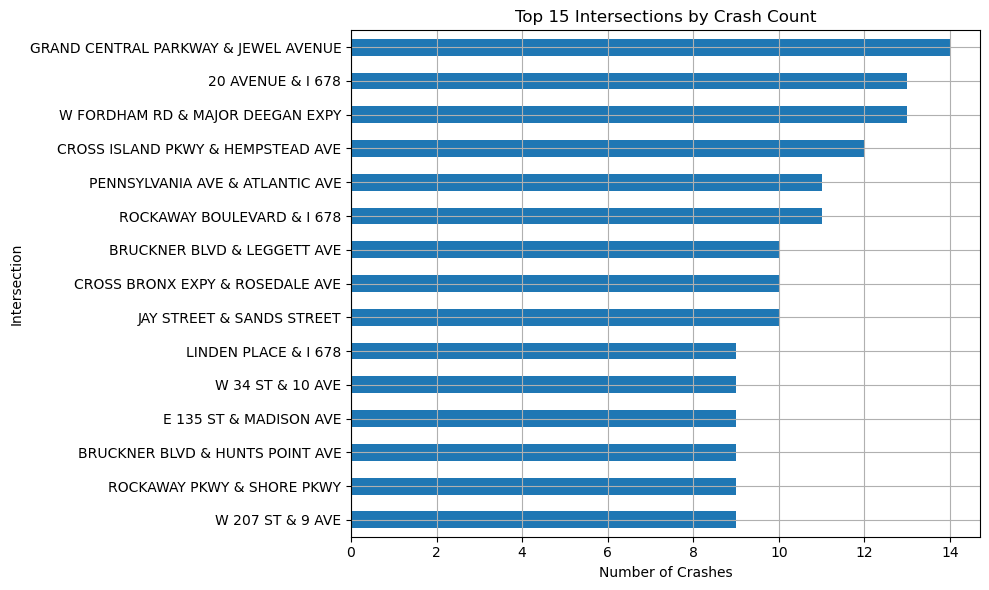

In [35]:
top_intersections.sort_values().plot(kind="barh")
plt.title("Top 15 Intersections by Crash Count")
plt.xlabel("Number of Crashes")
plt.ylabel("Intersection")
plt.tight_layout()
plt.show()

## Statistical Analysis

In this section, I use summary statistics and a chi-square test to check whether certain crash characteristics are associated with injury outcomes. Since the target outcome is categorical, a chi-square test is a reasonable method for checking whether two categorical variables are independent.

The result does not prove causation. It only helps show whether the distribution of injury crashes differs across categories.

In [36]:
# Injury crash rate by borough
injury_rate_by_borough = (
    collisions.groupby("borough")
    .agg(
        crashes=("collision_id", "count"),
        injury_crashes=("has_injury", "sum")
    )
    .assign(injury_rate=lambda x: x["injury_crashes"] / x["crashes"])
    .sort_values("injury_rate", ascending=False)
)

injury_rate_by_borough

,crashes,injury_crashes,injury_rate
borough,,,
Unknown,6873,3137,0.46
BRONX,3608,1471,0.41
BROOKLYN,7713,3088,0.40
MANHATTAN,4133,1623,0.39
QUEENS,5618,2123,0.38
STATEN ISLAND,908,295,0.32


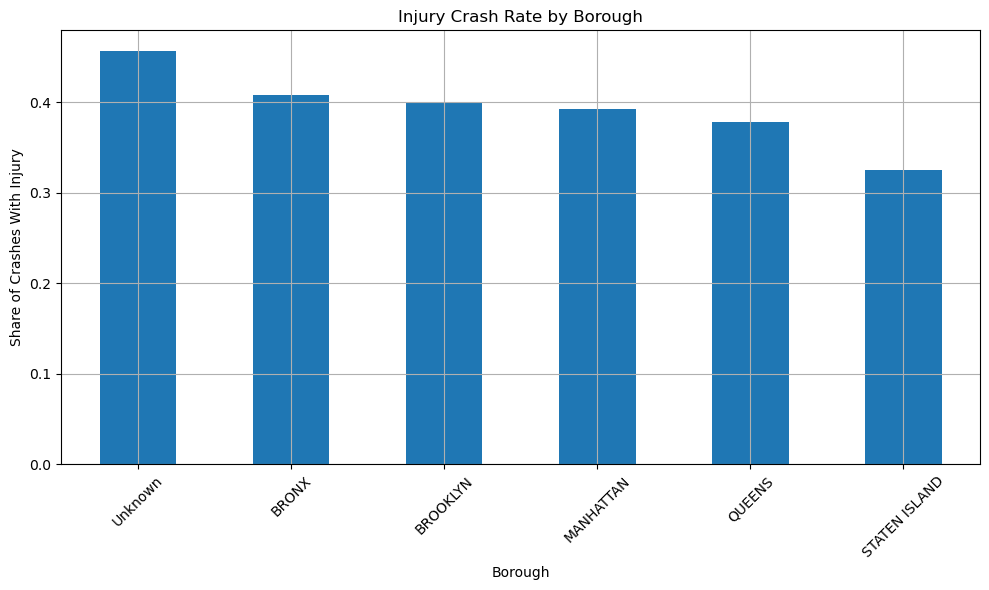

In [37]:
injury_rate_by_borough["injury_rate"].plot(kind="bar")
plt.title("Injury Crash Rate by Borough")
plt.xlabel("Borough")
plt.ylabel("Share of Crashes With Injury")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [38]:
# Chi-square test: Is injury outcome associated with borough?
from scipy.stats import chi2_contingency

contingency_borough = pd.crosstab(collisions["borough"], collisions["has_injury"])
chi2, p_value, dof, expected = chi2_contingency(contingency_borough)

print("Chi-square test: Borough vs Injury Outcome")
print(f"Chi-square statistic: {chi2:.4f}")
print(f"p-value: {p_value:.6f}")
print(f"Degrees of freedom: {dof}")

if p_value < 0.05:
    print("Result: There is a statistically significant association between borough and injury outcome.")
else:
    print("Result: There is not enough evidence to say borough and injury outcome are associated.")

Chi-square test: Borough vs Injury Outcome
Chi-square statistic: 119.5823
p-value: 0.000000
Degrees of freedom: 5
Result: There is a statistically significant association between borough and injury outcome.


In [39]:
# Injury crash rate for top specified contributing factors
factor_injury_rates = (
    specified_factors.groupby("contributing_factor_vehicle_1")
    .agg(
        crashes=("collision_id", "count"),
        injury_crashes=("has_injury", "sum"),
        fatalities=("total_killed", "sum")
    )
    .assign(injury_rate=lambda x: x["injury_crashes"] / x["crashes"])
    .query("crashes >= 100")
    .sort_values("injury_rate", ascending=False)
    .head(15)
)

factor_injury_rates

,crashes,injury_crashes,fatalities,injury_rate
contributing_factor_vehicle_1,,,,
Pedestrian/Bicyclist/Other Pedestrian Error/Confusion,286,243,1.00,0.85
Failure to Yield Right-of-Way,1742,1337,5.00,0.77
Traffic Control Disregarded,630,406,4.00,0.64
Brakes Defective,109,61,0.00,0.56
View Obstructed/Limited,270,143,0.00,0.53
Unsafe Speed,779,376,5.00,0.48
Reaction to Uninvolved Vehicle,259,116,0.00,0.45
Following Too Closely,1423,630,1.00,0.44
Driver Inattention/Distraction,6767,2984,16.00,0.44


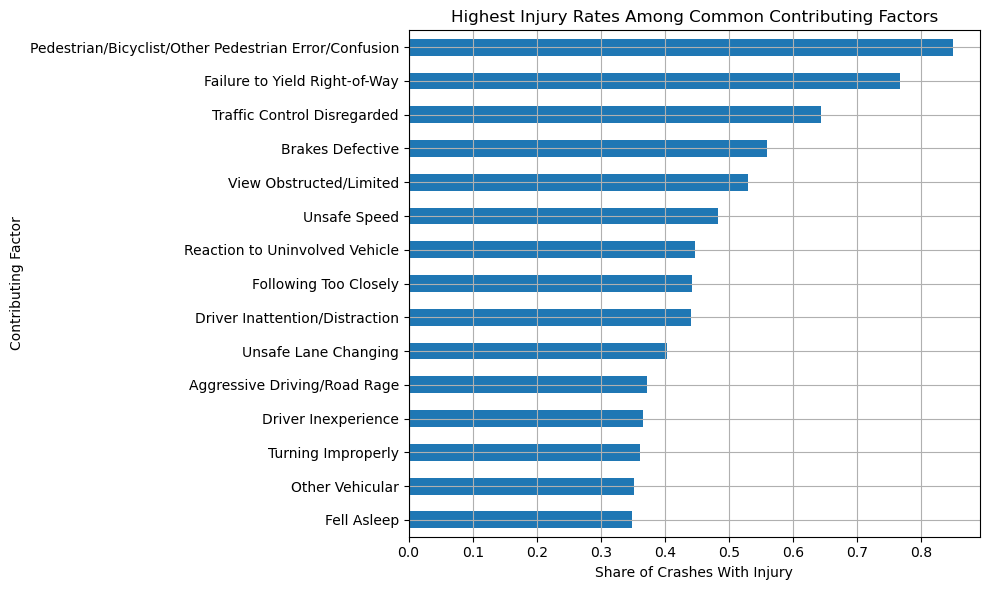

In [40]:
factor_injury_rates["injury_rate"].sort_values().plot(kind="barh")
plt.title("Highest Injury Rates Among Common Contributing Factors")
plt.xlabel("Share of Crashes With Injury")
plt.ylabel("Contributing Factor")
plt.tight_layout()
plt.show()


# Machine Learning Modeling

Although the primary focus of this project is data analysis and visualization, I also implemented a machine learning workflow to predict whether a collision resulted in at least one injury. 

This section demonstrates:
- baseline model development,
- model improvement,
- feature preprocessing,
- and implementation of a Scikit-learn Pipeline.

The target variable for the model is:
- `1` = collision resulted in at least one injury
- `0` = no reported injuries


In [ ]:

# Create binary target variable for injury-related collisions
collisions['injury_accident'] = (
    collisions['NUMBER OF PERSONS INJURED'] > 0
).astype(int)

# Select features for modeling
ml_df = collisions.copy()

features = [
    'borough',
    'hour',
    'month',
    'contributing_factor',
    'vehicle_type'
]

target = 'injury_accident'

ml_df = ml_df[features + [target]].dropna()

X = ml_df[features]
y = ml_df[target]

print("Modeling dataset shape:", ml_df.shape)
ml_df.head()



## Train-Test Split

I split the dataset into training and testing sets so the models could be evaluated on unseen data. This helps measure how well the models generalize to new collision records.


In [ ]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)



## Building the Scikit-learn Pipeline

To streamline preprocessing and modeling, I implemented a Scikit-learn Pipeline.

The pipeline handles:
- missing value imputation,
- feature scaling for numerical variables,
- one-hot encoding for categorical variables,
- and model training.

Using a pipeline improves reproducibility and keeps the workflow organized.


In [ ]:

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

numeric_features = ['hour', 'month']
categorical_features = ['borough', 'contributing_factor', 'vehicle_type']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)



## Baseline Model: Logistic Regression

I first implemented a Logistic Regression model as a baseline classifier. Logistic Regression is commonly used for binary classification problems and provides a useful benchmark for comparison.


In [ ]:

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

logistic_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

logistic_pipeline.fit(X_train, y_train)

logistic_preds = logistic_pipeline.predict(X_test)

print("Logistic Regression Accuracy:")
print(round(accuracy_score(y_test, logistic_preds), 4))

print("\nClassification Report:")
print(classification_report(y_test, logistic_preds))



## Final Model: Random Forest Classifier

Next, I implemented a Random Forest classifier to improve performance. Random Forest models are effective because they can capture nonlinear relationships and interactions between features.


In [ ]:

from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

rf_pipeline.fit(X_train, y_train)

rf_preds = rf_pipeline.predict(X_test)

print("Random Forest Accuracy:")
print(round(accuracy_score(y_test, rf_preds), 4))

print("\nClassification Report:")
print(classification_report(y_test, rf_preds))



## Confusion Matrix

The confusion matrix helps visualize the model's predictions by comparing predicted injury outcomes against actual injury outcomes.


In [ ]:

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_preds)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.show()



## Feature Importance

Feature importance analysis helps identify which variables had the strongest influence on the Random Forest model predictions.


In [ ]:

# Extract feature names after preprocessing
encoded_features = rf_pipeline.named_steps['preprocessor'] \
    .named_transformers_['cat'] \
    .named_steps['onehot'] \
    .get_feature_names_out(categorical_features)

all_features = numeric_features + list(encoded_features)

importances = rf_pipeline.named_steps['classifier'].feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': importances
})

top_features = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
).head(10)

plt.figure(figsize=(10,6))
plt.barh(top_features['Feature'], top_features['Importance'])
plt.title('Top 10 Random Forest Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.gca().invert_yaxis()
plt.show()


## Preparing Data for Tableau

For the Tableau dashboard, I want a cleaned version of the dataset with the engineered fields from this notebook. This export can be used to build an interactive dashboard with borough filters, time filters, severity filters, and a map of crash locations.

In [41]:
# Export a cleaned dataset for Tableau
output_path = Path("nyc_collisions_cleaned_for_tableau.csv")
collisions.to_csv(output_path, index=False)

print(f"Cleaned Tableau file saved as: {output_path}")
print(f"Rows exported: {len(collisions):,}")

Cleaned Tableau file saved as: nyc_collisions_cleaned_for_tableau.csv
Rows exported: 28,853


## Key Findings

Based on this analysis, the main findings are:

1. **Crash volume is not evenly distributed across boroughs.** Some boroughs report substantially more crashes than others, which may reflect differences in traffic volume, population density, road design, and reporting completeness.

2. **Time of day matters.** Crashes tend to vary by hour, and commute periods are important to review because they combine high traffic volume with pedestrians, cyclists, and motorists all sharing the road.

3. **Injuries are a major part of the crash profile.** Separating crashes into injury, fatal, and no-injury categories makes it easier to focus on public safety impact rather than crash counts alone.

4. **Driver inattention/distraction and failure to yield are important specified contributing factors.** These factors appear frequently and should be considered in safety campaigns and enforcement strategies.

5. **Pedestrians, cyclists, and motorists experience different injury and fatality patterns.** Breaking the analysis down by road user type provides more actionable insight than looking only at total injuries.

6. **Street and intersection-level analysis is valuable for hotspot identification.** The top streets and intersections can be used in Tableau to support location-specific recommendations.

## Recommendations

Based on the analysis, I identified several actionable recommendations that could help reduce collisions in New York City.

First, the data showed that Driver Inattention and Distraction was the most common contributing factor in accidents. Because of this, New York City could increase enforcement related to distracted driving, particularly during peak commuting hours.

The city could also expand public awareness campaigns focused on phone usage while driving, especially in boroughs with the highest collision counts such as Brooklyn and Queens.

Second, the collision data showed strong spikes during morning and evening rush hours. This suggests that traffic congestion and commuter behavior are major risk factors. To address this, traffic signal timing and congestion management strategies could be improved at high-risk intersections during peak hours.

Third, intersections and road segments with consistently high collision frequency should be prioritized for infrastructure improvements such as:

improved street lighting,
protected turn lanes,
pedestrian crossing enhancements,
and clearer traffic signage.

Finally, because failure to yield right-of-way and following too closely were also among the top contributing factors, defensive driving education and stricter enforcement of unsafe driving behaviors could potentially reduce injury-related collisions.

Overall, the findings suggest that many NYC traffic accidents may be preventable through a combination of driver awareness, targeted enforcement, and infrastructure improvements.

## Conclusion

This project analyzed NYC motor vehicle collision data using data cleaning, exploratory data analysis, statistical testing, and visualization. The analysis shows how crash patterns can be studied by location, time, severity, contributing factor, and road user type.

The most important takeaway is that collision analysis should not only focus on the number of crashes. A stronger safety analysis also considers injuries, fatalities, vulnerable road users, and where crashes are concentrated. These insights can support better traffic safety planning and provide a strong foundation for a Tableau dashboard and final presentation.